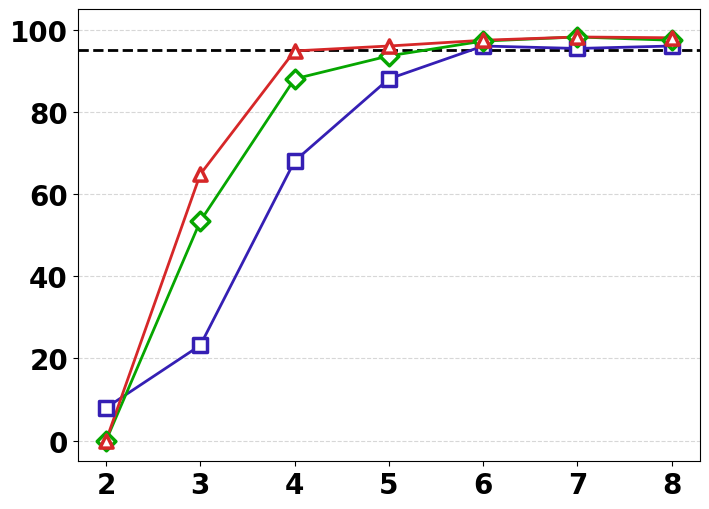

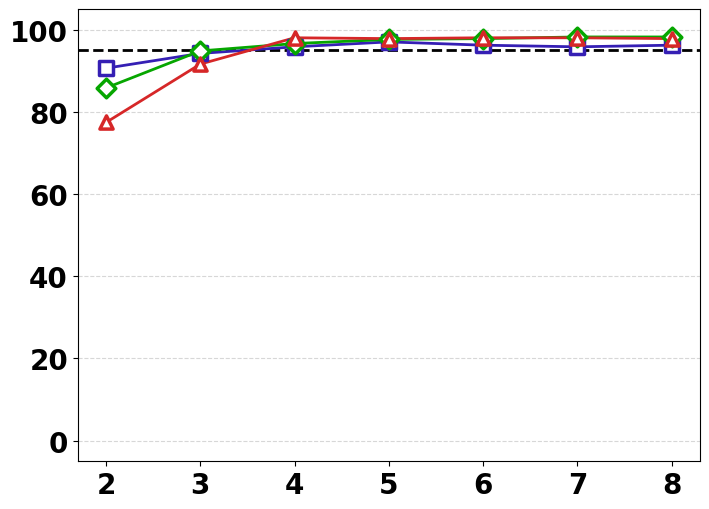

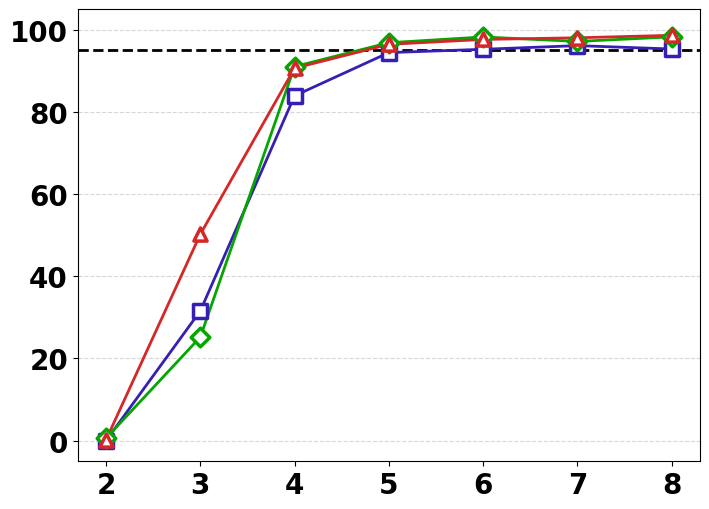

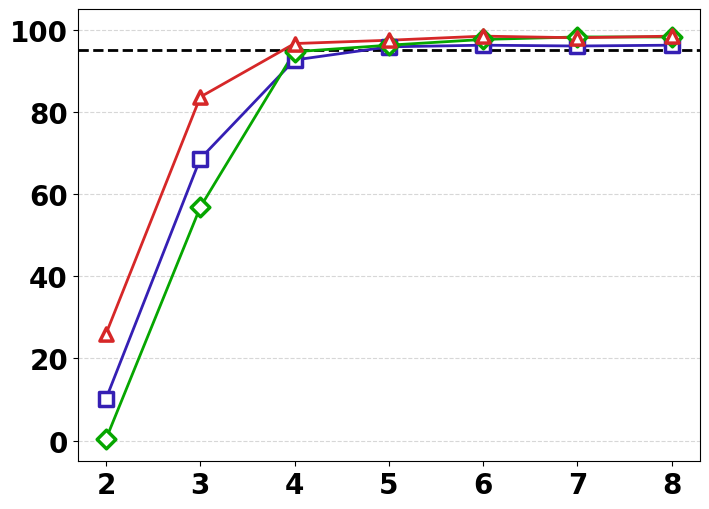

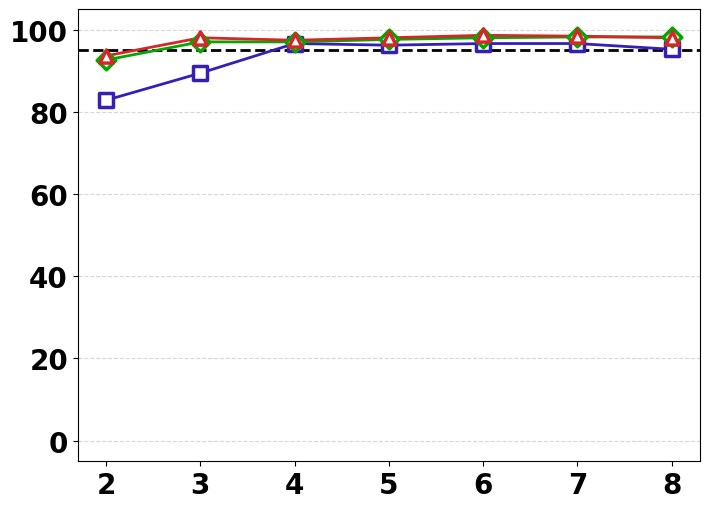

In [5]:
import pandas as pd
import glob
import re
import matplotlib.pyplot as plt
import numpy as np

# --- パターン定義（この順で図が出る） ---
patterns = [
    "/work/robomimic/csv/eval/lift/quantize/weight/unit*.csv",
    "/work/robomimic/csv/eval/lift/quantize/LUT/unit*.csv",
    "/work/robomimic/csv/eval/lift/quantize/CAM/calibration/u*.csv",
    "/work/robomimic/csv/eval/lift/quantize/digital/calibration/u*.csv",
    "/work/robomimic/csv/eval/lift/quantize/digital/fixed/u*.csv",
]

def extract_bit(filename: str):
    m = re.search(r"quantized_(\d+)bit", filename)
    return int(m.group(1)) if m else None

def extract_base_model(name: str):
    # seed 除去
    name = re.sub(r"_seed\d+", "", name)

    # quantized_xbit 以降を除去
    name = re.sub(r"_?quantized[_\-]?\d+\s*bit.*", "", name)

    # unit64 → u64 正規化
    name = name.replace("unit64", "u64")
    name = name.replace("unit128", "u128")
    name = name.replace("unit256", "u256")

    return name

# --- 描画設定 ---
custom_colors = {
    "ncp_u64_best":  "#351fb4",
    "u64":      "#351fb4",
    "ncp_u128_best": "#06a600",
    "u128":     "#06a600",
    "ncp_u256_best": "#d62728",
    "u256":     "#d62728",
}

markers = {
    "ncp_u64_best":  "s",
    "u64":      "s",
    "ncp_u128_best": "D",
    "u128":     "D",
    "ncp_u256_best": "^",
    "u256":     "^",
}

plot_order = ["ncp_u64_best","u64", "ncp_u128_best", "u128", "ncp_u256_best", "u256"]

# ===============================
# pattern ごとに「順番に」描画
# ===============================
for pattern in patterns:

    csv_files = sorted(glob.glob(pattern))
    if len(csv_files) == 0:
        continue

    df_list = []
    for file in csv_files:
        bit = extract_bit(file)
        if bit is None:
            continue
        df = pd.read_csv(file)
        df["bit"] = bit
        df["base_model"] = df["name"].apply(extract_base_model)
        df_list.append(df)

    if len(df_list) == 0:
        continue

    df_all = pd.concat(df_list, ignore_index=True)

    # --- 集計 ---
    df_agg = (
        df_all.groupby(["base_model", "bit"])["success_rate"]
              .mean()
              .reset_index()
    )
    df_agg = df_agg[df_agg["bit"] != 1]

    # ===== 描画 =====
    plt.figure(figsize=(7.2, 5.2))

    # 95% 基準線（背面）
    plt.axhline(
        95,
        color="black",
        linestyle="--",
        linewidth=2.0,
        zorder=-10,
    )

    for base_model in plot_order:
        df_m = df_agg[df_agg["base_model"] == base_model].sort_values("bit")
        if df_m.empty:
            continue

        bits  = df_m["bit"].values
        means = df_m["success_rate"].values * 100

        color  = custom_colors[base_model]
        marker = markers[base_model]

        plt.plot(bits, means, color=color, linewidth=2.0, zorder=5)
        plt.scatter(
            bits, means,
            marker=marker,
            s=90,
            facecolors="white",
            edgecolors=color,
            linewidths=2.5,
            zorder=6,
        )

    plt.ylim(-5, 105)
    plt.xticks(sorted(df_agg["bit"].unique()))

    plt.tick_params(axis="both", labelsize=20)
    for lbl in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
        lbl.set_fontweight("bold")

    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


                             base_model  bit  n_runs
0    ncp_u128_best_seed1_quantized_1bit    1       1
1    ncp_u128_best_seed1_quantized_2bit    2       1
2    ncp_u128_best_seed1_quantized_3bit    3       1
3    ncp_u128_best_seed1_quantized_4bit    4       1
4    ncp_u128_best_seed1_quantized_5bit    5       1
..                                  ...  ...     ...
115   ncp_u64_best_seed5_quantized_4bit    4       1
116   ncp_u64_best_seed5_quantized_5bit    5       1
117   ncp_u64_best_seed5_quantized_6bit    6       1
118   ncp_u64_best_seed5_quantized_7bit    7       1
119   ncp_u64_best_seed5_quantized_8bit    8       1

[120 rows x 3 columns]
警告: 5本でないグループがあります


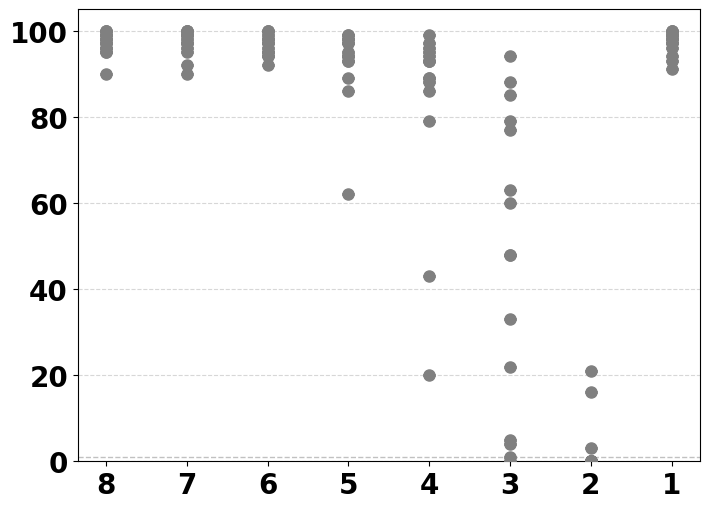

In [20]:
# --- 全部結合と集計（デジタル固定パラメータ版） ---
import numpy as np  # np を使うので追加

def extract_bit(filename: str):
    m = re.search(r"quantized_(\d+)bit", filename)
    return int(m.group(1)) if m else None

def extract_base_model_from_name(name: str):
    # 例: "unit64_quantized_2bit" -> "unit64"
    m = re.match(r"(unit\d+)_", name)
    return m.group(1) if m else name

df_list = []
for file in csv_files:
    bit = extract_bit(file)
    if bit is None:
        continue
    df = pd.read_csv(file)
    df["bit"] = bit
    # name カラムから base_model を付与
    df["base_model"] = df["name"].apply(extract_base_model_from_name)
    df_list.append(df)

if len(df_list) == 0:
    print("対象CSVが見つかりません:", csv_files)
else:
    df_all = pd.concat(df_list, ignore_index=True)
    df_count = (
        df_all.groupby(["base_model", "bit"])
            .size()
            .reset_index(name="n_runs")
    )
    print(df_count)
    if not (df_count["n_runs"] == 5).all():
        print("警告: 5本でないグループがあります")
    df_all = df_all[~df_all["base_model"].str.contains("512")]
    df_agg = (
        df_all.groupby(["base_model", "bit"])["success_rate"]
              .agg(["mean", "std"])
              .reset_index()
    )
    df_agg["std"] = df_agg["std"].fillna(0)

    custom_colors = {
        "unit64":  "#e377c2",
        "unit128": "#ff7f0e",
        "unit256": "#d62728",
    }
    offsets = {
        "unit64":  0.13,
        "unit128": 0.00,
        "unit256": -0.13,
    }

    plt.figure(figsize=(7.2, 5.2))
    for base_model, df_m in df_agg.groupby("base_model"):
        df_m = df_m.sort_values("bit", ascending=False)
        bits  = df_m["bit"].values
        means = df_m["mean"].values * 100
        stds  = df_m["std"].values * 100
        lower = np.maximum(means - stds, 0)
        upper = np.minimum(means + stds, 100)
        x = bits + offsets.get(base_model, 0.0)
        color = custom_colors.get(base_model, "gray")
        plt.plot(x, means, color=color, linewidth=1.6, alpha=0.8, zorder=9)
        plt.errorbar(
            x,
            means,
            yerr=[means - lower, upper - means],
            fmt="o",
            color=color,
            markersize=8,
            elinewidth=1.4,
            capsize=4,
            capthick=2.0,
            zorder=10,
            label=base_model.replace("_best", "")
        )

    # ...ループ終了後、描画設定の直前に追加...
    plt.axhline(1.0, color="#999", linestyle="--", linewidth=1, alpha=0.6)  # 100% 基準線
    plt.tick_params(axis="both", labelsize=20)
    for lbl in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
        lbl.set_fontweight("bold")
    plt.ylim(0, 105)
    plt.gca().invert_xaxis()
    plt.xticks(sorted(df_agg["bit"].unique(), reverse=True))
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

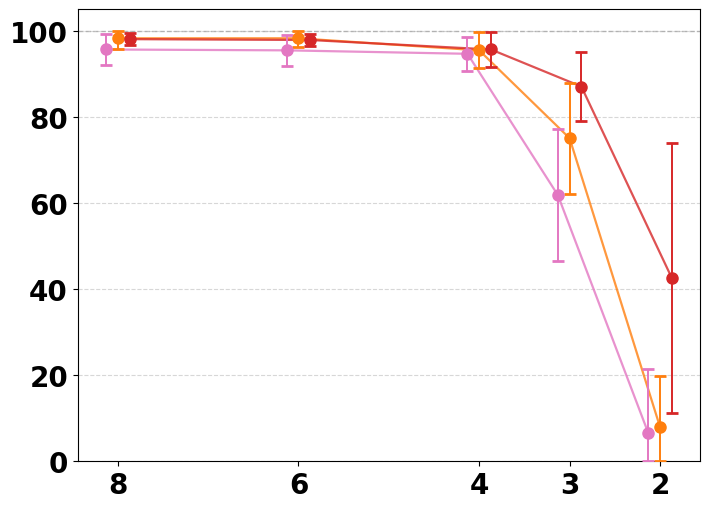

In [2]:
# Digital Variable Params Quantization (2bit, 3bit, 4bit, 6bit, 8bit)
import pandas as pd
import glob
import re
import matplotlib.pyplot as plt
import numpy as np

# --- CSV をすべて読み込み ---
csv_files = glob.glob(
    "/work/robomimic/csv/eval/lift/quantize/digital/clip/unit*.csv"
)

def extract_bit(filename: str):
    """SRAMunit128_quantized_2bit.csv -> 2"""
    m = re.search(r"quantized_(\d+)bit", filename)
    return int(m.group(1)) if m else None

def extract_base_model_from_filename(filename: str):
    """SRAMunit128_quantized_2bit.csv -> unit128"""
    m = re.search(r"(unit\d+)", filename)
    return m.group(1) if m else None

df_list = []
for file in csv_files:
    bit = extract_bit(file)
    base_model = extract_base_model_from_filename(file)
    if bit is None or base_model is None:
        continue
    df = pd.read_csv(file)
    df["bit"] = bit
    df["base_model"] = base_model
    df_list.append(df)

if len(df_list) == 0:
    print("対象CSVが見つかりません:", csv_files)
else:
    # --- 全部結合 ---
    df_all = pd.concat(df_list, ignore_index=True)

    # --- base_model × bit ごとの success_rate mean / std ---
    df_agg = (
        df_all
        .groupby(["base_model", "bit"])["success_rate"]
        .agg(["mean", "std"])
        .reset_index()
    )
    df_agg["std"] = df_agg["std"].fillna(0)

    # --- カスタムカラーパレット & オフセット ---
    custom_colors = {
        "unit64": "#e377c2",
        "unit128": "#ff7f0e",
        "unit256": "#d62728",
    }
    offsets = {
        "unit64":  0.13,
        "unit128":  0.00,
        "unit256": -0.13,
    }

    plt.figure(figsize=(7.2, 5.2))

    for base_model, df_m in df_agg.groupby("base_model"):
        color = custom_colors.get(base_model, "gray")
        df_m = df_m.sort_values("bit", ascending=False)

        bits  = df_m["bit"].values
        means = df_m["mean"].values * 100  # %
        stds  = df_m["std"].values * 100   # %

        lower = np.maximum(means - stds, 0)
        upper = np.minimum(means + stds, 100)

        x = bits + offsets.get(base_model, 0.0)

        # 平均線
        plt.plot(
            x, means,
            color=color,
            linewidth=1.6,
            alpha=0.8,
            zorder=9,
        )

        # 点 + エラーバー
        plt.errorbar(
            x,
            means,
            yerr=[means - lower, upper - means],
            fmt="o",
            color=color,
            markersize=8,
            elinewidth=1.4,
            capsize=4,
            capthick=2.0,
            zorder=10,
            label=base_model,
        )

    # --- 軸・スタイル ---
    plt.axhline(100, color="#999", linestyle="--", linewidth=1, alpha=0.6)  # 100% 基準線
    plt.tick_params(axis="both", labelsize=20, labelfontfamily="DejaVu Sans")
    for lbl in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
        lbl.set_fontweight("bold")

    plt.ylim(0, 105)
    plt.gca().invert_xaxis()
    plt.xticks(sorted(df_agg["bit"].unique(), reverse=True))

    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

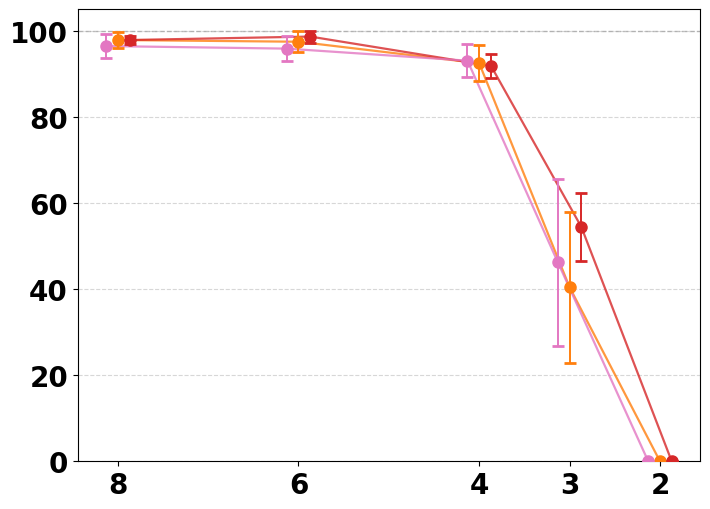

In [4]:
# CAM Quantization (2bit, 3bit, 4bit, 6bit, 8bit)
import pandas as pd
import glob
import re
import matplotlib.pyplot as plt
import numpy as np

# --- CSV をすべて読み込み ---
csv_files = glob.glob(
    "/work/robomimic/csv/eval/lift/quantize/CAM/clip/unit*.csv"
)

def extract_bit(filename: str):
    """unit128_quantized_2bit.csv -> 2"""
    m = re.search(r"quantized_(\d+)bit", filename)
    return int(m.group(1)) if m else None

def extract_base_model_from_filename(filename: str):
    """unit128_quantized_2bit.csv -> unit128"""
    m = re.search(r"(unit\d+)", filename)
    return m.group(1) if m else None

df_list = []
for file in csv_files:
    bit = extract_bit(file)
    base_model = extract_base_model_from_filename(file)
    if bit is None or base_model is None:
        continue
    df = pd.read_csv(file)
    df["bit"] = bit
    df["base_model"] = base_model
    df_list.append(df)

if len(df_list) == 0:
    print("対象CSVが見つかりません:", csv_files)
else:
    # --- 全部結合 ---
    df_all = pd.concat(df_list, ignore_index=True)

    # --- base_model × bit ごとの success_rate mean / std ---
    df_agg = (
        df_all
        .groupby(["base_model", "bit"])["success_rate"]
        .agg(["mean", "std"])
        .reset_index()
    )
    df_agg["std"] = df_agg["std"].fillna(0)

    # --- カスタムカラーパレット & オフセット ---
    custom_colors = {
        "unit64": "#e377c2",
        "unit128": "#ff7f0e",
        "unit256": "#d62728",
    }
    offsets = {
        "unit64":  0.13,
        "unit128":  0.00,
        "unit256": -0.13,
    }

    plt.figure(figsize=(7.2, 5.2))

    for base_model, df_m in df_agg.groupby("base_model"):
        color = custom_colors.get(base_model, "gray")
        df_m = df_m.sort_values("bit", ascending=False)

        bits  = df_m["bit"].values
        means = df_m["mean"].values * 100  # %
        stds  = df_m["std"].values * 100   # %

        lower = np.maximum(means - stds, 0)
        upper = np.minimum(means + stds, 100)

        x = bits + offsets.get(base_model, 0.0)

        # 平均線
        plt.plot(
            x, means,
            color=color,
            linewidth=1.6,
            alpha=0.8,
            zorder=9,
        )

        # 点 + エラーバー
        plt.errorbar(
            x,
            means,
            yerr=[means - lower, upper - means],
            fmt="o",
            color=color,
            markersize=8,
            elinewidth=1.4,
            capsize=4,
            capthick=2.0,
            zorder=10,
            label=base_model,
        )

    # --- 軸・スタイル ---
    plt.axhline(100, color="#999", linestyle="--", linewidth=1, alpha=0.6)  # 100% 基準線
    plt.tick_params(axis="both", labelsize=20, labelfontfamily="DejaVu Sans")
    for lbl in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
        lbl.set_fontweight("bold")

    plt.ylim(0, 105)
    plt.gca().invert_xaxis()
    plt.xticks(sorted(df_agg["bit"].unique(), reverse=True))

    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

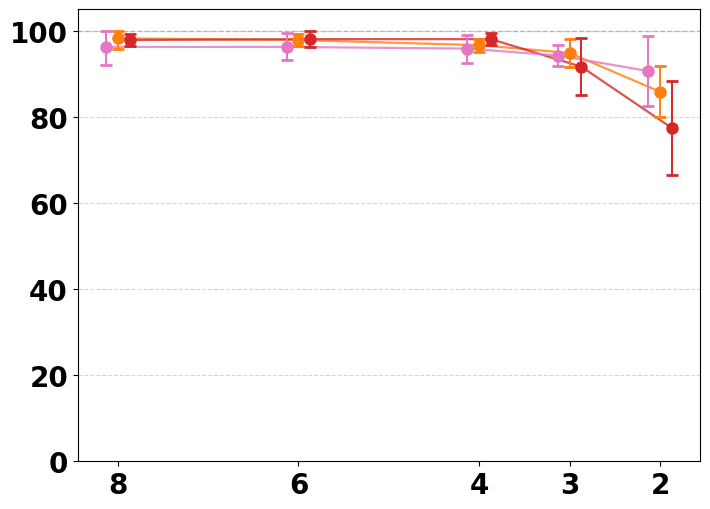

In [10]:
# LUT Quantization (2bit, 3bit, 4bit, 6bit, 8bit)
import pandas as pd
import glob
import re
import matplotlib.pyplot as plt
import numpy as np

# --- CSV をすべて読み込み ---
csv_files = glob.glob(
    "/work/robomimic/csv/eval/lift/quantize/LUT/unit*.csv"
)

def extract_bit(filename: str):
    """unit128_quantized_2bit.csv -> 2"""
    m = re.search(r"quantized_(\d+)bit", filename)
    return int(m.group(1)) if m else None

def extract_base_model_from_filename(filename: str):
    """unit128_quantized_2bit.csv -> unit128"""
    m = re.search(r"(unit\d+)", filename)
    return m.group(1) if m else None

df_list = []
for file in csv_files:
    bit = extract_bit(file)
    base_model = extract_base_model_from_filename(file)
    if bit is None or base_model is None:
        continue
    df = pd.read_csv(file)
    df["bit"] = bit
    df["base_model"] = base_model
    df_list.append(df)

if len(df_list) == 0:
    print("対象CSVが見つかりません:", csv_files)
else:
    # --- 全部結合 ---
    df_all = pd.concat(df_list, ignore_index=True)

    # --- base_model × bit ごとの success_rate mean / std ---
    df_agg = (
        df_all
        .groupby(["base_model", "bit"])["success_rate"]
        .agg(["mean", "std"])
        .reset_index()
    )
    df_agg["std"] = df_agg["std"].fillna(0)

    # --- カスタムカラーパレット & オフセット ---
    custom_colors = {
        "unit64": "#e377c2",
        "unit128": "#ff7f0e",
        "unit256": "#d62728",
    }
    offsets = {
        "unit64":  0.13,
        "unit128":  0.00,
        "unit256": -0.13,
    }

    plt.figure(figsize=(7.2, 5.2))

    for base_model, df_m in df_agg.groupby("base_model"):
        color = custom_colors.get(base_model, "gray")
        df_m = df_m.sort_values("bit", ascending=False)

        bits  = df_m["bit"].values
        means = df_m["mean"].values * 100  # %
        stds  = df_m["std"].values * 100   # %

        lower = np.maximum(means - stds, 0)
        upper = np.minimum(means + stds, 100)

        x = bits + offsets.get(base_model, 0.0)

        # 平均線
        plt.plot(
            x, means,
            color=color,
            linewidth=1.6,
            alpha=0.8,
            zorder=9,
        )

        # 点 + エラーバー
        plt.errorbar(
            x,
            means,
            yerr=[means - lower, upper - means],
            fmt="o",
            color=color,
            markersize=8,
            elinewidth=1.4,
            capsize=4,
            capthick=2.0,
            zorder=10,
            label=base_model,
        )

    # --- 軸・スタイル ---
    plt.axhline(100, color="#999", linestyle="--", linewidth=1, alpha=0.6)  # 100% 基準線
    plt.tick_params(axis="both", labelsize=20, labelfontfamily="DejaVu Sans")
    for lbl in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
        lbl.set_fontweight("bold")

    plt.ylim(0, 105)
    plt.gca().invert_xaxis()
    plt.xticks(sorted(df_agg["bit"].unique(), reverse=True))

    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()